In [82]:
import numpy as np
import pandas as pd
import os
import sys
import time
import sklearn.tree
import sklearn.linear_model
import sklearn.metrics
import sklearn.ensemble
from pretty_print_sklearn_tree import pretty_print_sklearn_tree
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import PredefinedSplit
import matplotlib
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8') # pretty matplotlib plots

import seaborn as sns
sns.set('notebook', font_scale=1.25, style='whitegrid')

# Some preliminary code
def add_username(username) -> None:
    plt.text(0.95, 0.95, username, ha="right", va="top", transform=plt.gca().transAxes, fontsize=10, color="gray", alpha=0.7)

def print_separator() -> None:
    print("="*50)

# Load all data from train/valid/test

In [50]:
data_dir = 'data_product_reviews/'

### Load training

In [ ]:
# Load training - using pandas to inspect first
x_train_df = pd.read_csv(os.path.join(data_dir, 'x_train.csv'), header=None)
y_train_df = pd.read_csv(os.path.join(data_dir, 'y_train.csv'), header=None)

# Exclude the first rows as they are headers
x_train_df = x_train_df.iloc[1:]
y_train_df = y_train_df.iloc[1:]

x_train = x_train_df.values
y_train = y_train_df[0]

### Load validation set

In [ ]:
x_valid_df = pd.read_csv(os.path.join(data_dir, 'x_valid.csv'), header=None)
y_valid_df = pd.read_csv(os.path.join(data_dir, 'y_valid.csv'), header=None)

# Exclude the first rows as they are headers
x_valid_df = x_valid_df.iloc[1:]
y_valid_df = y_valid_df.iloc[1:]

x_valid = x_valid_df.values
y_valid = y_valid_df[0]

### Load test set 

In [ ]:
# Load test set
x_test_df = pd.read_csv(os.path.join(data_dir, 'x_test.csv'), header=None)
y_test_df = pd.read_csv(os.path.join(data_dir, 'y_test.csv'), header=None)

# Exclude the first rows as they are headers
x_test_df = x_test_df.iloc[1:]
y_test_df = y_test_df.iloc[1:]

x_test = x_test_df.values
y_test = y_test_df[0]

### Load vocabulary as a list of strings and pack train, val sets

In [54]:
# Load vocabulary from the header of x_train.csv
vocab_df = pd.read_csv(os.path.join(data_dir, 'x_train.csv'), nrows=0)
vocab_list = list(vocab_df.columns)

print(f"\nTraining set: {x_train.shape[0]} samples, {x_train.shape[1]} features")
print(f"Validation set: {x_valid.shape[0]} samples")
print(f"Test set: {x_test.shape[0]} samples")
print(f"Vocabulary size: {len(vocab_list)}")

# Pack training and validation sets
x_tr_NF = x_train
y_tr_N = y_train

x_va_MF = x_valid
y_va_M = y_valid

split_index = np.concatenate([
    -np.ones(x_train.shape[0], dtype=int),
    np.zeros(x_valid.shape[0], dtype=int)
])

x_trainval = np.vstack([x_train, x_valid])
y_trainval = np.concatenate([y_train, y_valid])

my_splitter = PredefinedSplit(split_index)


Training set: 6346 samples, 7729 features
Validation set: 792 samples
Test set: 793 samples
Vocabulary size: 7729


# Problem 1: Decision Trees

## 1A: Train a simple tree with depth 3

In [55]:
simple_tree = sklearn.tree.DecisionTreeClassifier(
    criterion='gini',
    max_depth=3,
    min_samples_leaf=1,
    min_samples_split=2,
    random_state=101
)

### **Fit the tree** 

**TODO Train on the training set** in the next coding cell

In [56]:
simple_tree.fit(x_tr_NF, y_tr_N)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,101
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


### **Figure 1: Print Tree** 

Use a helper function from the starter code

In [57]:
pretty_print_sklearn_tree(simple_tree, feature_names=vocab_list)

The binary tree structure has 15 nodes.
- depth   0 has    1 nodes, of which    0 are leaves
- depth   1 has    2 nodes, of which    0 are leaves
- depth   2 has    4 nodes, of which    0 are leaves
- depth   3 has    8 nodes, of which    8 are leaves
The decision tree:  (Note: Y = 'yes' to above question; N = 'no')
Decision: X['great'] <= 0.50?
  Y Decision: X['excel'] <= 0.50?
    Y Decision: X['disappoint'] <= 0.50?
      Y Leaf: p(y=1 | this leaf) = 0.430 (1 total training examples)
      N Leaf: p(y=1 | this leaf) = 0.114 (1 total training examples)
    N Decision: X['disappoint'] <= 0.50?
      Y Leaf: p(y=1 | this leaf) = 0.903 (1 total training examples)
      N Leaf: p(y=1 | this leaf) = 0.429 (1 total training examples)
  N Decision: X['return'] <= 0.50?
    Y Decision: X['bad'] <= 0.50?
      Y Leaf: p(y=1 | this leaf) = 0.745 (1 total training examples)
      N Leaf: p(y=1 | this leaf) = 0.415 (1 total training examples)
    N Decision: X['movie'] <= 0.50?
      Y Leaf: p(y

In [58]:
print_separator()
print("Internal Nodes with Same-Class Children")
print_separator()

# Examine the tree structure
tree = simple_tree.tree_
n_nodes = tree.node_count
children_left = tree.children_left
children_right = tree.children_right
feature = tree.feature
value = tree.value

same_class_parent = False

print(children_left)
print(children_right)

# Check each internal node
for i in range(n_nodes):
    left_child = children_left[i]
    right_child = children_right[i]
    
    # If it's an internal node (has children)
    if left_child != right_child:
        # Check if both children are leaves
        left_is_leaf = (children_left[left_child] == children_right[left_child])
        right_is_leaf = (children_left[right_child] == children_right[right_child])
        
        if left_is_leaf and right_is_leaf:
            # Get class predictions for both leaves
            left_class_1_prob = value[left_child][0][1] / value[left_child][0].sum()
            right_class_1_prob = value[right_child][0][1] / value[right_child][0].sum()
            
            left_pred_class = 1 if left_class_1_prob > 0.5 else 0
            right_pred_class = 1 if right_class_1_prob > 0.5 else 0
            
            if left_pred_class == right_pred_class:
                same_class_parent = True
                print(f"\nFound: Node {i} (split on feature '{vocab_list[feature[i]]}')")
                print(f"  Left leaf:  p(y=1) = {left_class_1_prob:.3f} → predicts class {left_pred_class}")
                print(f"  Right leaf: p(y=1) = {right_class_1_prob:.3f} → predicts class {right_pred_class}")
                print(f"  Both children predict class {left_pred_class}!")

if same_class_parent:
    print("""
    Even though both children predict the same class, the split is still useful:
    
    1. CONFIDENCE LEVELS DIFFER: The probabilities are different, indicating
       varying confidence in the prediction. One leaf might be very confident
       (p=0.90) while the other is less certain (p=0.55).
    
    2. PURITY IMPROVEMENT: The split creates more homogeneous regions, reducing
       variance within each leaf even if predictions stay the same.
    
    3. FUTURE SPLITS: If we allowed the tree to grow deeper, these branches
       might eventually diverge to different classes at lower levels.
    """)
else:
    print("\nNo internal nodes found with both children as same-class leaves.")
    print("This means every split in the tree creates a meaningful divergence")
    print("in predictions between left and right branches.")

print_separator()

Internal Nodes with Same-Class Children
[ 1  2  3 -1 -1  6 -1 -1  9 10 -1 -1 13 -1 -1]
[ 8  5  4 -1 -1  7 -1 -1 12 11 -1 -1 14 -1 -1]

Found: Node 2 (split on feature 'disappoint')
  Left leaf:  p(y=1) = 0.430 → predicts class 0
  Right leaf: p(y=1) = 0.114 → predicts class 0
  Both children predict class 0!

    Even though both children predict the same class, the split is still useful:

    1. CONFIDENCE LEVELS DIFFER: The probabilities are different, indicating
       varying confidence in the prediction. One leaf might be very confident
       (p=0.90) while the other is less certain (p=0.55).

    2. PURITY IMPROVEMENT: The split creates more homogeneous regions, reducing
       variance within each leaf even if predictions stay the same.

    3. FUTURE SPLITS: If we allowed the tree to grow deeper, these branches
       might eventually diverge to different classes at lower levels.
    


## 1B : Find best Decision Tree with grid search

In [59]:
base_tree = sklearn.tree.DecisionTreeClassifier(
    criterion='gini',
    min_samples_split=2,
    random_state=101
)

param_grid_tree = {
    'max_depth': [2, 8, 32, 128],
    'min_samples_leaf': [1, 3, 9]
}
tree_searcher = sklearn.model_selection.GridSearchCV(
    base_tree,
    param_grid=param_grid_tree,
    scoring='balanced_accuracy',
    cv=my_splitter,
    return_train_score=True,
    refit=False,
    verbose=True
)

### Build the best decision tree

In [60]:
tree_searcher.fit(x_trainval, y_trainval)
results_df = pd.DataFrame(tree_searcher.cv_results_)
print(results_df[['param_max_depth', 'param_min_samples_leaf', 
                   'mean_train_score', 'mean_test_score']].to_string())
print(f"\nBest parameters: {tree_searcher.best_params_}")
print(f"Best validation balanced accuracy: {tree_searcher.best_score_:.4f}")

Fitting 1 folds for each of 12 candidates, totalling 12 fits
    param_max_depth  param_min_samples_leaf  mean_train_score  mean_test_score
0                 2                       1          0.640429         0.633931
1                 2                       3          0.640429         0.633931
2                 2                       9          0.640429         0.633931
3                 8                       1          0.726505         0.698887
4                 8                       3          0.721935         0.697599
5                 8                       9          0.712791         0.696208
6                32                       1          0.918197         0.727378
7                32                       3          0.877218         0.732380
8                32                       9          0.814975         0.713458
9               128                       1          0.996216         0.730313
10              128                       3          0.924198         

**TODO Build the Best Tree on the training set** in the next coding cell



In [61]:
best_tree = sklearn.tree.DecisionTreeClassifier(
    criterion='gini',
    min_samples_split=2,
    random_state=101,
    **tree_searcher.best_params_
)
best_tree.fit(x_tr_NF, y_tr_N)

,criterion,'gini'
,splitter,'best'
,max_depth,32
,min_samples_split,2
,min_samples_leaf,3
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,101
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


### Interpret the best decision tree

In [62]:
pretty_print_sklearn_tree(best_tree, feature_names=vocab_list)

The binary tree structure has 817 nodes.
- depth   0 has    1 nodes, of which    0 are leaves
- depth   1 has    2 nodes, of which    0 are leaves
- depth   2 has    4 nodes, of which    0 are leaves
- depth   3 has    8 nodes, of which    0 are leaves
- depth   4 has   16 nodes, of which    6 are leaves
- depth   5 has   20 nodes, of which    5 are leaves
- depth   6 has   30 nodes, of which   14 are leaves
- depth   7 has   32 nodes, of which   18 are leaves
- depth   8 has   28 nodes, of which   12 are leaves
- depth   9 has   32 nodes, of which   11 are leaves
- depth  10 has   42 nodes, of which   21 are leaves
- depth  11 has   42 nodes, of which   23 are leaves
- depth  12 has   38 nodes, of which   17 are leaves
- depth  13 has   42 nodes, of which   21 are leaves
- depth  14 has   42 nodes, of which   25 are leaves
- depth  15 has   34 nodes, of which   18 are leaves
- depth  16 has   32 nodes, of which   14 are leaves
- depth  17 has   36 nodes, of which   23 are leaves
- dep

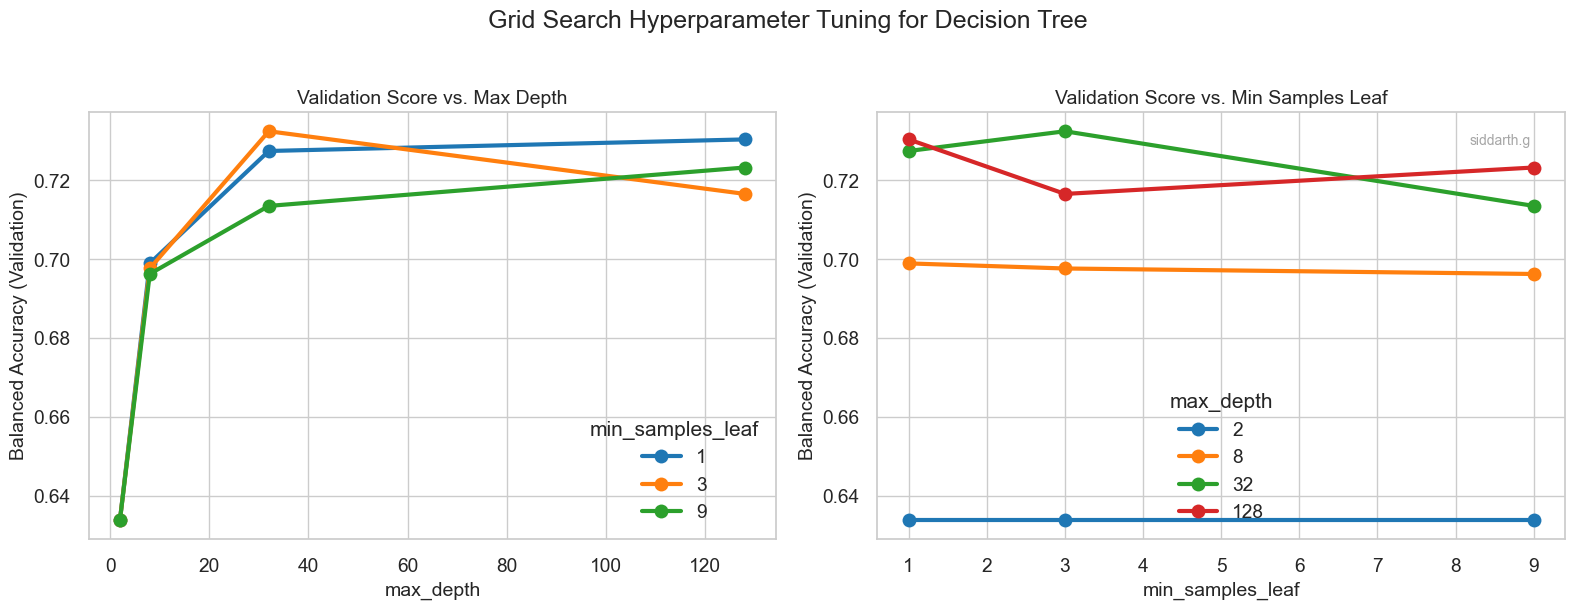

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Grid Search Hyperparameter Tuning for Decision Tree', fontsize=18, y=1.02)

# Get unique values for grouping
min_samples_leaf_values = results_df['param_min_samples_leaf'].unique()
max_depth_values = results_df['param_max_depth'].unique()

# Define colors for different lines
colors = plt.cm.tab10(range(len(min_samples_leaf_values)))

# Plot 1: Validation Score vs. Max Depth
for idx, min_leaf in enumerate(min_samples_leaf_values):
    # Filter data for this min_samples_leaf value
    mask = results_df['param_min_samples_leaf'] == min_leaf
    data_subset = results_df[mask].sort_values('param_max_depth')
    
    axes[0].plot(
        data_subset['param_max_depth'],
        data_subset['mean_test_score'],
        marker='o',
        markersize=10,
        linewidth=3,
        label=f'{min_leaf}',
        color=colors[idx]
    )

axes[0].set_title('Validation Score vs. Max Depth', fontsize=14)
axes[0].set_xlabel('max_depth', fontsize=14)
axes[0].set_ylabel('Balanced Accuracy (Validation)', fontsize=14)
axes[0].legend(title='min_samples_leaf')
axes[0].grid(True)

# Plot 2: Validation Score vs. Min Samples Leaf
colors2 = plt.cm.tab10(range(len(max_depth_values)))

for idx, max_d in enumerate(max_depth_values):
    # Filter data for this max_depth value
    mask = results_df['param_max_depth'] == max_d
    data_subset = results_df[mask].sort_values('param_min_samples_leaf')
    
    axes[1].plot(
        data_subset['param_min_samples_leaf'],
        data_subset['mean_test_score'],
        marker='o',
        markersize=10,
        linewidth=3,
        label=f'{max_d}',
        color=colors2[idx]
    )

axes[1].set_title('Validation Score vs. Min Samples Leaf', fontsize=14)
axes[1].set_xlabel('min_samples_leaf', fontsize=14)
axes[1].set_ylabel('Balanced Accuracy (Validation)', fontsize=14)
axes[1].legend(title='max_depth')
axes[1].grid(True)

plt.tight_layout()
add_username('siddarth.g')
plt.show()

# Problem 2: Random forest

## 2A: Train a random forest with default settings

In [64]:
simple_forest = sklearn.ensemble.RandomForestClassifier(
    n_estimators=100,
    criterion='gini',
    max_features='sqrt',
    max_depth=3,
    min_samples_leaf=1,
    min_samples_split=2,
    random_state=101)

### Fit the forest

**TODO Train on the training set** in the next coding cell

In [65]:
simple_forest.fit(x_tr_NF, y_tr_N)

,n_estimators,100
,criterion,'gini'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## 2B & Table 2: Feature Importances

In [72]:
print_separator()
feature_importances = simple_forest.feature_importances_

# Get top 10 important words
top_10_indices = np.argsort(feature_importances)[::-1][:10]
top_10_words = [vocab_list[i] for i in top_10_indices]
top_10_scores = feature_importances[top_10_indices]

# Get 10 least important words
unimportant_indices = np.argsort(feature_importances)[:10]
bottom_10_words = [vocab_list[i] for i in unimportant_indices]
bottom_10_scores = feature_importances[unimportant_indices]

print("\nTable 2: Feature Importances")
print(f"\n{'Important Words':<20} {'Score':<12} | {'Unimportant Words':<20} {'Score':<12}")
print_separator()
for i in range(10):
    important = f"{top_10_words[i]:<20} {top_10_scores[i]:<12.6f}"

    unimportant = f"{bottom_10_words[i]:<20} {bottom_10_scores[i]:<12.6f}"
    
    print(f"{important} | {unimportant}")

# ------------------

# Get 10 random unimportant words (importance < 0.00001)
unimportant_mask = feature_importances < 0.00001
unimportant_indices = np.where(unimportant_mask)[0]
unimportant_words = [vocab_list[i] for i in unimportant_indices]
unimportant_scores = feature_importances[unimportant_indices]

print(f"\n{'Unimportant Words':<20} {'Score':<12}")
print_separator()
for i in range(10):
    unimportant = f"{unimportant_words[i]:<20} {unimportant_scores[i]:<12.6f}"
    
    print(f"{unimportant}")

print(f"\nTotal number of features with importance < 0.00001: {len(unimportant_words)}")


Table 2: Feature Importances

Important Words      Score        | Unimportant Words    Score       
return               0.032990     | product              0.000000    
excel                0.029485     | leave_it             0.000000    
great                0.028984     | time                 0.000000    
worst                0.028407     | work_out             0.000000    
poor                 0.026748     | trip_to              0.000000    
disappoint           0.024952     | six_months           0.000000    
your_money           0.018002     | i_have               0.000000    
i_love               0.017955     | read                 0.000000    
the_best             0.017662     | make                 0.000000    
don't                0.017654     | if_you               0.000000    

Unimportant Words    Score       
good                 0.000000    
time                 0.000000    
i_have               0.000000    
read                 0.000000    
make                 0.00000

## 2C: Best Random Forest via grid search



This block might take 2-10 minutes. 

If yours runs significantly longer, try this out on Google Colab instead.

In [73]:
base_forest = sklearn.ensemble.RandomForestClassifier(
    criterion='gini',
    min_samples_split=2,
    min_samples_leaf=1,
    n_estimators=100,
    random_state=101
)

In [74]:
param_grid_forest = {
    'max_features': [3, 10, 33, 100, 333],
    'max_depth': [16, 32]
}

forest_searcher = sklearn.model_selection.GridSearchCV(
    base_forest,
    param_grid=param_grid_forest,
    scoring='balanced_accuracy',
    cv=my_splitter,
    return_train_score=True,
    refit=False,
    verbose=1,
    n_jobs=-1
)

### Do the search!

In [75]:
forest_searcher.fit(x_trainval, y_trainval)

Fitting 1 folds for each of 10 candidates, totalling 10 fits


,estimator,RandomForestC...dom_state=101)
,param_grid,"{'max_depth': [16, 32], 'max_features': [3, 10, ...]}"
,scoring,'balanced_accuracy'
,n_jobs,-1
,refit,False
,cv,"PredefinedSpl...hape=(7138,)))"
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,n_estimators,100


### Display search results

In [76]:
print("\nGrid Search Results:")
results_df_forest = pd.DataFrame(forest_searcher.cv_results_)
print(results_df_forest[['param_max_features', 'param_max_depth', 
                          'mean_train_score', 'mean_test_score']].to_string())

print(f"\nBest parameters: {forest_searcher.best_params_}")
print(f"Best validation balanced accuracy: {forest_searcher.best_score_:.4f}")


Grid Search Results:
   param_max_features  param_max_depth  mean_train_score  mean_test_score
0                   3               16          0.908283         0.751761
1                  10               16          0.925010         0.840997
2                  33               16          0.923600         0.842439
3                 100               16          0.920745         0.839402
4                 333               16          0.871229         0.784194
5                   3               32          0.968174         0.796507
6                  10               32          0.970070         0.843626
7                  33               32          0.964402         0.851204
8                 100               32          0.969748         0.835434
9                 333               32          0.952712         0.812187

Best parameters: {'max_depth': 32, 'max_features': 33}
Best validation balanced accuracy: 0.8512


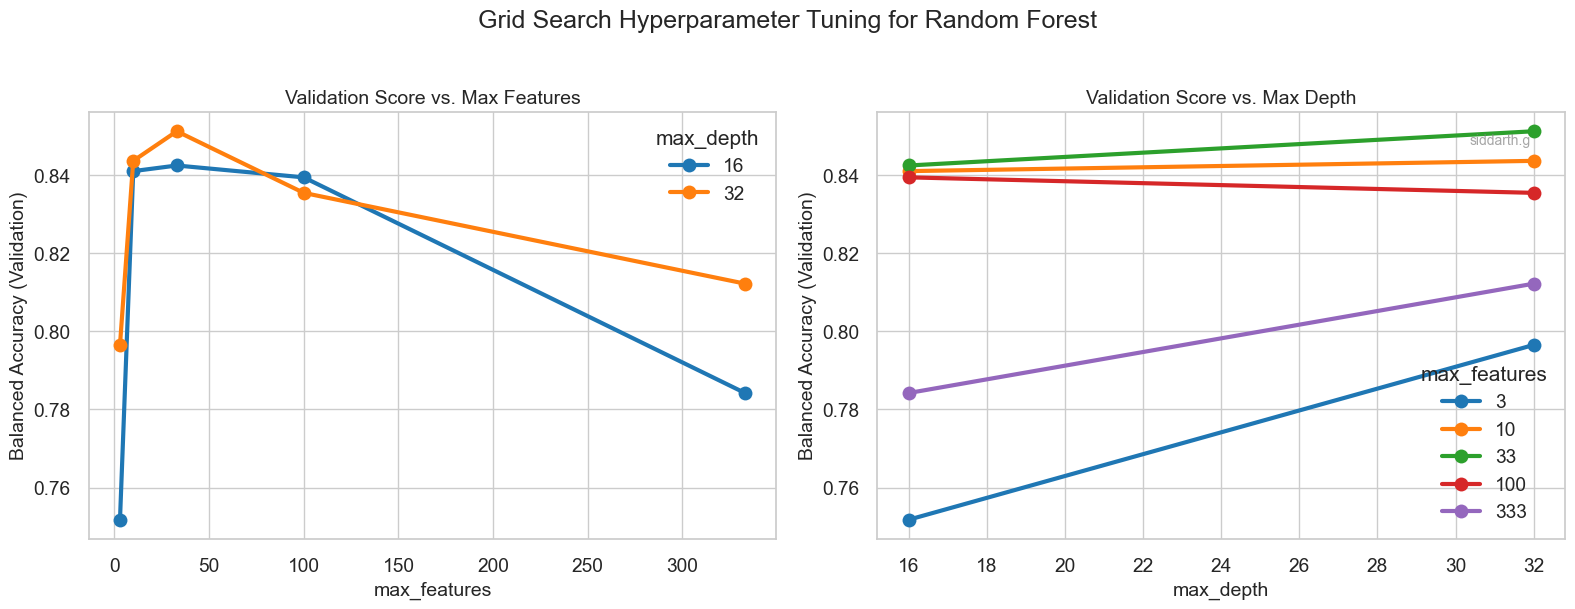

In [77]:
results_df_forest_plot = pd.DataFrame(forest_searcher.cv_results_)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Grid Search Hyperparameter Tuning for Random Forest', fontsize=18, y=1.02)

# Get unique values for grouping
max_depth_values = results_df_forest_plot['param_max_depth'].unique()
max_features_values = results_df_forest_plot['param_max_features'].unique()

# Define colors
colors = plt.cm.tab10(range(len(max_depth_values)))

# Plot 1: Validation Score vs. Max Features
for idx, max_d in enumerate(max_depth_values):
    mask = results_df_forest_plot['param_max_depth'] == max_d
    data_subset = results_df_forest_plot[mask].sort_values('param_max_features')
    
    axes[0].plot(
        data_subset['param_max_features'],
        data_subset['mean_test_score'],
        marker='o',
        markersize=10,
        linewidth=3,
        label=f'{max_d}',
        color=colors[idx]
    )

axes[0].set_title('Validation Score vs. Max Features', fontsize=14)
axes[0].set_xlabel('max_features', fontsize=14)
axes[0].set_ylabel('Balanced Accuracy (Validation)', fontsize=14)
axes[0].legend(title='max_depth')
axes[0].grid(True)

# Plot 2: Validation Score vs. Max Depth
colors2 = plt.cm.tab10(range(len(max_features_values)))

for idx, max_f in enumerate(max_features_values):
    mask = results_df_forest_plot['param_max_features'] == max_f
    data_subset = results_df_forest_plot[mask].sort_values('param_max_depth')
    
    axes[1].plot(
        data_subset['param_max_depth'],
        data_subset['mean_test_score'],
        marker='o',
        markersize=10,
        linewidth=3,
        label=f'{max_f}',
        color=colors2[idx]
    )

axes[1].set_title('Validation Score vs. Max Depth', fontsize=14)
axes[1].set_xlabel('max_depth', fontsize=14)
axes[1].set_ylabel('Balanced Accuracy (Validation)', fontsize=14)
axes[1].legend(title='max_features')
axes[1].grid(True)

plt.tight_layout()
add_username('siddarth.g')
plt.show()

### Build the best random forest using the best hyperparameters found in 2B 

This is necessary so you have the specific best performing forest in your workspace.

Train *only* on training set (do not merge train and valid)


In [78]:
best_forest = sklearn.ensemble.RandomForestClassifier(
    criterion='gini',
    min_samples_split=2,
    min_samples_leaf=1,
    n_estimators=100,
    random_state=101,
    **forest_searcher.best_params_
)
best_forest.fit(x_tr_NF, y_tr_N)

,n_estimators,100
,criterion,'gini'
,max_depth,32
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,33
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


TABLE : Comparison of Methods

       Method  Max Depth  Num Trees Train BAcc Valid BAcc Test BAcc
  Simple Tree          3          1      0.646      0.645     0.646
    Best Tree         32          1      0.877      0.732     0.749
Simple Forest          3        100      0.819      0.797     0.778
  Best Forest         32        100      0.964      0.851     0.837


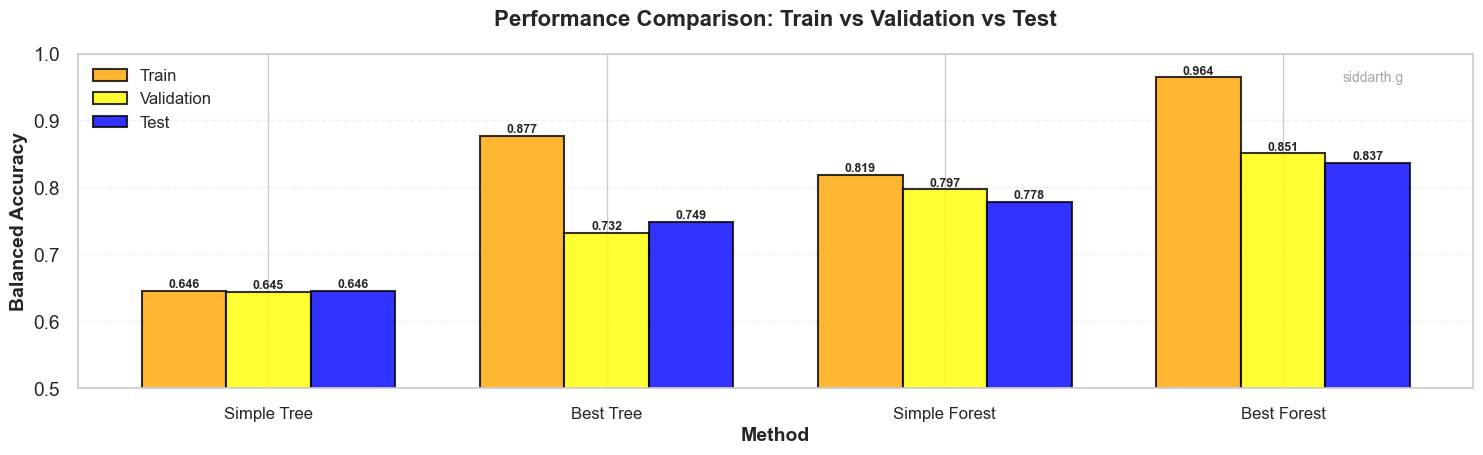

In [86]:
print_separator()
print("TABLE : Comparison of Methods")
print_separator()

models = {
    'Simple Tree': (simple_tree, 3, 1),
    'Best Tree': (best_tree, tree_searcher.best_params_['max_depth'], 1),
    'Simple Forest': (simple_forest, 3, 100),
    'Best Forest': (best_forest, forest_searcher.best_params_['max_depth'], 100)
}

results = []

for name, (model, max_depth, n_trees) in models.items():
    # Training balanced accuracy
    train_pred = model.predict(x_train)
    train_bacc = sklearn.metrics.balanced_accuracy_score(y_train, train_pred)
    
    # Validation balanced accuracy
    valid_pred = model.predict(x_valid)
    valid_bacc = sklearn.metrics.balanced_accuracy_score(y_valid, valid_pred)
    
    # Test balanced accuracy
    test_pred = model.predict(x_test)
    test_bacc = sklearn.metrics.balanced_accuracy_score(y_test, test_pred)
    
    results.append({
        'Method': name,
        'Max Depth': max_depth,
        'Num Trees': n_trees,
        'Train BAcc': train_bacc,
        'Valid BAcc': valid_bacc,
        'Test BAcc': test_bacc
    })

results_df_final = pd.DataFrame(results)

# Print table with formatted values
print_df = results_df_final.copy()
print_df['Train BAcc'] = print_df['Train BAcc'].apply(lambda x: f"{x:.3f}")
print_df['Valid BAcc'] = print_df['Valid BAcc'].apply(lambda x: f"{x:.3f}")
print_df['Test BAcc'] = print_df['Test BAcc'].apply(lambda x: f"{x:.3f}")
print("\n" + print_df.to_string(index=False))

# ===================== VISUALIZATION =====================

fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)

# --- Plot 1: Grouped Bar Chart ---
ax1 = fig.add_subplot(gs[0, :])
x = np.arange(len(results_df_final))
width = 0.25

bars1 = ax1.bar(x - width, results_df_final['Train BAcc'], width, 
                label='Train', color='orange', alpha=0.8, edgecolor='black', linewidth=1.5)
bars2 = ax1.bar(x, results_df_final['Valid BAcc'], width, 
                label='Validation', color='yellow', alpha=0.8, edgecolor='black', linewidth=1.5)
bars3 = ax1.bar(x + width, results_df_final['Test BAcc'], width, 
                label='Test', color='blue', alpha=0.8, edgecolor='black', linewidth=1.5)

ax1.set_xlabel('Method', fontsize=14, fontweight='bold')
ax1.set_ylabel('Balanced Accuracy', fontsize=14, fontweight='bold')
ax1.set_title('Performance Comparison: Train vs Validation vs Test', fontsize=16, fontweight='bold', pad=20)
ax1.set_xticks(x)
ax1.set_xticklabels(results_df_final['Method'], fontsize=12)
ax1.legend(fontsize=12, loc='upper left')
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.set_ylim([0.5, 1.0])

# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

add_username('siddarth.g')
plt.show()